In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score, KFold, learning_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/Final_Weather_Data.csv")
df.head()

,District,Date,Rain (mm),Min Temp (°C),Max Temp (°C),Min Humidity (%),Max Humidity (%),Min Wind Speed (Kmph),Max Wind Speed (Kmph),Temp_Range,...,Avg_Temp,Avg_Humidity,Month,Day,Year,Temp_Humidity_Range,AvgTemp_AvgHumidity,WindInteraction,precipitation,precipitation_flag
0,Adilabad,2023-02-01,0.0,17.483333,31.788889,46.577778,83.716667,0.483333,7.377778,14.305556,...,24.636111,65.147222,2.0,1.0,2023,531.292438,1604.974205,50.865679,0.00,0
1,Bhadradri Kothagudem,2023-02-01,0.0,18.721739,33.269565,42.369565,96.143478,0.000000,5.921739,14.547826,...,25.995652,69.256522,2.0,1.0,2023,782.293535,1800.368450,35.066994,0.00,0
2,Hanumakonda,2023-02-01,0.0,19.678571,32.135714,46.585714,93.521429,0.000000,6.214286,12.457143,...,25.907143,70.053571,2.0,1.0,2023,584.684898,1814.887883,38.617347,0.00,0
3,Hyderabad,2023-02-01,0.0,20.818750,30.900000,40.012500,78.606250,0.000000,16.412500,10.081250,...,25.859375,59.309375,2.0,1.0,2023,389.073242,1533.703369,269.370156,0.04,0
4,Jagtial,2023-02-01,0.0,19.433333,33.555556,43.938889,95.327778,0.000000,4.772222,14.122222,...,26.494444,69.633333,2.0,1.0,2023,725.725309,1844.896481,22.774105,0.00,0


In [ ]:
print(df.shape)
print("--------------------------")
df.columns

(24123, 22)
--------------------------


Index(['District', 'Date', 'Rain (mm)', 'Min Temp (°C)', 'Max Temp (°C)',
       'Min Humidity (%)', 'Max Humidity (%)', 'Min Wind Speed (Kmph)',
       'Max Wind Speed (Kmph)', 'Temp_Range', 'Humidity_Range', 'Wind_Range',
       'Avg_Temp', 'Avg_Humidity', 'Month', 'Day', 'Year',
       'Temp_Humidity_Range', 'AvgTemp_AvgHumidity', 'WindInteraction',
       'precipitation', 'precipitation_flag'],
      dtype='object')

In [ ]:
df_district = df.groupby(["District", "Date"])[['Rain (mm)', 'Min Temp (°C)',
       'Max Temp (°C)', 'Min Humidity (%)', 'Max Humidity (%)',
       'Min Wind Speed (Kmph)', 'Max Wind Speed (Kmph)','Temp_Range','Humidity_Range','Wind_Range','Avg_Temp','Avg_Humidity','Temp_Humidity_Range','AvgTemp_AvgHumidity','WindInteraction','precipitation','precipitation_flag']].mean().reset_index()

In [ ]:
df_district.shape

(24123, 19)

In [ ]:
df_district.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24123 entries, 0 to 24122
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   District               24123 non-null  object 
 1   Date                   24123 non-null  object 
 2   Rain (mm)              24123 non-null  float64
 3   Min Temp (°C)          24123 non-null  float64
 4   Max Temp (°C)          24123 non-null  float64
 5   Min Humidity (%)       24123 non-null  float64
 6   Max Humidity (%)       24123 non-null  float64
 7   Min Wind Speed (Kmph)  24123 non-null  float64
 8   Max Wind Speed (Kmph)  24123 non-null  float64
 9   Temp_Range             24123 non-null  float64
 10  Humidity_Range         24123 non-null  float64
 11  Wind_Range             24123 non-null  float64
 12  Avg_Temp               24123 non-null  float64
 13  Avg_Humidity           24123 non-null  float64
 14  Temp_Humidity_Range    24123 non-null  float64
 15  Av

In [ ]:
df_district['Date'] = pd.to_datetime(df_district['Date'])


In [ ]:
df_district = df_district.sort_values(by=['District','Date']).reset_index(drop=True)


In [ ]:
# 1. Temperature Range (difference between max and min temp)
df_district["Temp_Range"] = df_district["Max Temp (°C)"] - df_district["Min Temp (°C)"]

# 2. Humidity Range
df_district["Humidity_Range"] = df_district["Max Humidity (%)"] - df_district["Min Humidity (%)"]

# 3. Wind Speed Range
df_district["Wind_Range"] = df_district["Max Wind Speed (Kmph)"] - df_district["Min Wind Speed (Kmph)"]

# 4. Average Temperature
df_district["Avg_Temp"] = (df_district["Max Temp (°C)"] + df_district["Min Temp (°C)"]) / 2

# 5. Average Humidity
df_district["Avg_Humidity"] = (df_district["Max Humidity (%)"] + df_district["Min Humidity (%)"]) / 2

# 6. Month and Day from Date (seasonal patterns are very important in rainfall)
df_district["Date"] = pd.to_datetime(df_district["Date"])
df_district["Month"] = df_district["Date"].dt.month
df_district["Day"] = df_district["Date"].dt.day
df_district["Year"] = df_district["Date"].dt.year

# Interaction between ranges
df_district['Temp_Humidity_Range'] = df_district['Temp_Range'] * df_district['Humidity_Range']
df_district['AvgTemp_AvgHumidity'] = df_district['Avg_Temp'] * df_district['Avg_Humidity']
df_district['WindInteraction'] = df_district['Wind_Range'] * df_district['Max Wind Speed (Kmph)']

df_district["temp_rain_interaction"] = df_district["Temp_Range"] * df_district["precipitation"]




In [ ]:
df_district.describe()


,Date,Rain (mm),Min Temp (°C),Max Temp (°C),Min Humidity (%),Max Humidity (%),Min Wind Speed (Kmph),Max Wind Speed (Kmph),Temp_Range,Humidity_Range,...,Avg_Humidity,Temp_Humidity_Range,AvgTemp_AvgHumidity,WindInteraction,precipitation,precipitation_flag,Month,Day,Year,temp_rain_interaction
count,24123,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000,...,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000,24123.000000
mean,2024-01-31 23:59:59.999999744,3.007550,21.782708,34.184883,48.074038,90.683293,0.211001,8.398844,12.402176,42.609255,...,69.378665,574.625061,1924.925672,77.450355,1.855419,0.368072,6.519836,15.738714,2023.585499,15.433369
min,2023-02-01 00:00:00,0.000000,7.883333,20.838889,9.287500,32.892308,0.000000,0.650000,1.265217,-2.040000,...,23.033333,-3.202800,822.220800,0.422500,0.000000,0.000000,1.000000,1.000000,2023.000000,0.000000
25%,2023-08-02 00:00:00,0.000000,19.015192,31.732456,33.808013,88.120635,0.000000,6.200000,9.766667,33.590546,...,61.553414,334.099034,1647.070511,38.130625,0.000000,0.000000,4.000000,8.000000,2023.000000,0.000000
50%,2024-02-01 00:00:00,0.000000,22.796154,33.636842,47.127778,95.194444,0.000000,8.012500,12.711765,43.720833,...,70.942308,560.810059,1951.454735,63.263669,0.040000,0.000000,7.000000,16.000000,2024.000000,0.502909
75%,2024-08-02 00:00:00,1.064643,24.517029,36.278571,61.109524,97.566667,0.153846,10.218350,15.244722,52.574457,...,78.803010,786.750421,2230.820835,101.310521,0.510000,1.000000,10.000000,23.000000,2024.000000,5.061710
max,2025-01-31 00:00:00,284.300000,32.244444,45.555556,97.026087,100.000000,6.303704,26.200000,23.473333,79.259259,...,98.306522,1757.219753,2642.552977,686.276250,123.825000,1.000000,12.000000,31.000000,2025.000000,761.151368
std,NaN,10.119718,3.914571,3.797019,18.042982,10.526194,0.542197,3.074181,3.824565,13.798956,...,13.060329,309.247609,355.856887,56.726283,5.910180,0.482291,3.449622,8.804103,0.572293,44.365643


In [ ]:
df_district.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24123 entries, 0 to 24122
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   District               24123 non-null  object        
 1   Date                   24123 non-null  datetime64[ns]
 2   Rain (mm)              24123 non-null  float64       
 3   Min Temp (°C)          24123 non-null  float64       
 4   Max Temp (°C)          24123 non-null  float64       
 5   Min Humidity (%)       24123 non-null  float64       
 6   Max Humidity (%)       24123 non-null  float64       
 7   Min Wind Speed (Kmph)  24123 non-null  float64       
 8   Max Wind Speed (Kmph)  24123 non-null  float64       
 9   Temp_Range             24123 non-null  float64       
 10  Humidity_Range         24123 non-null  float64       
 11  Wind_Range             24123 non-null  float64       
 12  Avg_Temp               24123 non-null  float64       
 13  A

In [ ]:
df_district.isnull().sum()     # Gives the sum of missing values in the dataframe


,0
District,0
Date,0
Rain (mm),0
Min Temp (°C),0
Max Temp (°C),0
Min Humidity (%),0
Max Humidity (%),0
Min Wind Speed (Kmph),0
Max Wind Speed (Kmph),0
Temp_Range,0


In [ ]:
X = df_district[['Min Temp (°C)', 'Max Temp (°C)', 'Min Humidity (%)','Max Humidity (%)', 'Min Wind Speed (Kmph)', 'Max Wind Speed (Kmph)','Temp_Range', 'Humidity_Range', 'Wind_Range','Avg_Temp','Avg_Humidity','Month','Year','Temp_Humidity_Range','AvgTemp_AvgHumidity','WindInteraction','precipitation','precipitation_flag','temp_rain_interaction']]

y = df_district['Rain (mm)']

In [ ]:
y_log = np.log1p(y)  # log(1+y)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)


In [ ]:
model = XGBRegressor()
model.fit(X_train, y_train)

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(feature_importance_df)


                  Feature  Importance
10           Avg_Humidity    0.315260
14    AvgTemp_AvgHumidity    0.154516
17     precipitation_flag    0.068535
18  temp_rain_interaction    0.064876
3        Max Humidity (%)    0.060893
16          precipitation    0.054599
11                  Month    0.053678
8              Wind_Range    0.048784
6              Temp_Range    0.028240
5   Max Wind Speed (Kmph)    0.020839
15        WindInteraction    0.020263
12                   Year    0.018889
0           Min Temp (°C)    0.016895
13    Temp_Humidity_Range    0.016043
2        Min Humidity (%)    0.013593
9                Avg_Temp    0.012210
7          Humidity_Range    0.012015
1           Max Temp (°C)    0.010247
4   Min Wind Speed (Kmph)    0.009624


In [ ]:
# After preparing your dataframe (df)
selected_features = [
    "Avg_Humidity",
    "AvgTemp_AvgHumidity",
    "precipitation",
    "Max Humidity (%)",
    "Month",
    "WindInteraction",
    "Temp_Range",
    "Wind_Range",
    "precipitation_flag",
    "Temp_Humidity_Range",
    "temp_rain_interaction"
]

X_selected = X[selected_features]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_log, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_split=5,max_depth=30)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)


RMSE: 0.501043953044062
R2: 0.7360088728055255


In [ ]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 7. Train
xgb.fit(X_train, y_train)
# 8. Predict
y_pred = xgb.predict(X_test)
# 9. Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost RMSE:", rmse)
print("XGBoost R2:", r2)


XGBoost RMSE: 0.48293797530852783
XGBoost R2: 0.7547435745891182


In [ ]:
#from sklearn.model_selection import RandomizedSearchCV

#param_grid = {
    #'n_estimators': [100, 200, 300],
    #'max_depth': [None, 10, 20, 30],
    #'min_samples_split': [2, 5, 10]
#}

#search = RandomizedSearchCV(model, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42)
#search.fit(X_train, y_train)

#print("Best params:", search.best_params_)


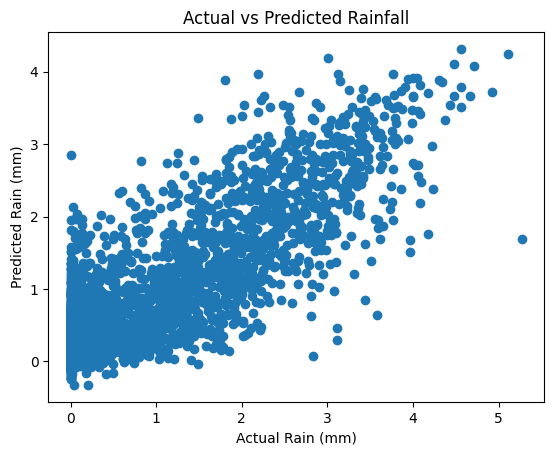

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rain (mm)")
plt.ylabel("Predicted Rain (mm)")
plt.title("Actual vs Predicted Rainfall")
plt.show()


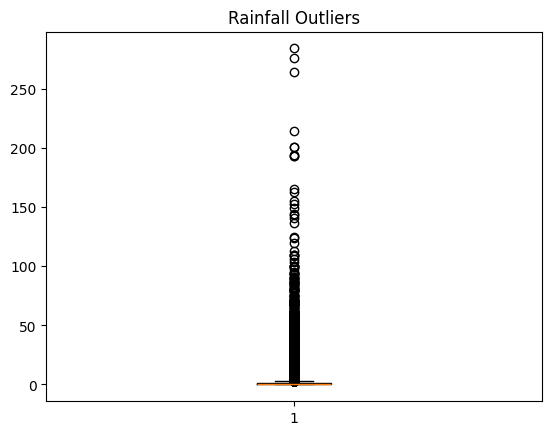

In [ ]:
plt.boxplot(df['Rain (mm)'])
plt.title("Rainfall Outliers")
plt.show()

In [ ]:
# Convert rainfall (y) into binary labels
# Assuming y is your original target (rainfall in mm)
y_class = np.where(y > 0, 1, 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_class, test_size=0.2, random_state=42)

# Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluation
print("Accuracy:", accura cy_score(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred))


Accuracy: 0.8540932642487047
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.87      2768
           1       0.83      0.82      0.83      2057

    accuracy                           0.85      4825
   macro avg       0.85      0.85      0.85      4825
weighted avg       0.85      0.85      0.85      4825



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
